# Component Separation

In [1]:
import os
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# Find path to test dataset
os.chdir("/obs/dtibi/STL-Dev/tests/certification_notebooks/2D_FFT_Torch")
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

DATA_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../"
    + os.path.basename(PARENT_DIR)
    + DATA_PATH.split(os.path.basename(PARENT_DIR))[-1],
)

from STL_main.comp_sep_5channels import baseline_comp_sep
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test
Using device: cuda


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [3]:
# Load target map
s_U, s_Q, d_I = np.load(DATA_PATH + "/" + "truth.npy")[::2, :, :]
s_U = torch.from_numpy(s_U).float().to(device)  # Target map of the U component
s_Q = torch.from_numpy(s_Q).float().to(device)  # Target map of the Q component
d_I = torch.from_numpy(d_I).float().to(device)  # Ancillary data

SNR = 1  # Signal-to-noise ratio (ratio between the standard deviation of the signal and the noise)
c_U_std = torch.std(s_U) * SNR  # Standard deviation of the noise for the U component
c_Q_std = torch.std(s_Q) * SNR  # Standard deviation of the noise for the Q component

In [11]:
# Build ensemble of contamination maps (first two maps are used for the building of the observed maps, and validating the process)
N =10
H, W = s_U.shape
torch.manual_seed(0)  # For reproducibility
c_U = torch.randn(N + 2, H, W).to(device) * c_U_std
c_Q = torch.randn(N + 2, H, W).to(device) * c_Q_std

# Observed maps
d_U = s_U + c_U[0]  # Observed map of the U component
d_Q = s_Q + c_Q[0]  # Observed map of the Q component
    
# Full phase (5-channel phase) component separation
(s_U_opt, s_Q_opt), loss_history = baseline_comp_sep(
    d_U=d_U,
    d_Q=d_Q,
    d_I=d_I,
    c_U=c_U[2:], 
    c_Q=c_Q[2:],
    max_iter=100,
    batch_size=5,
    STL_DataClass=STL_2D_FFT_Torch
)

[LBFGS] iter    5 - loss: 1.170093e+02


RuntimeError: The size of tensor a (5882) must match the size of tensor b (64522) at non-singleton dimension 0

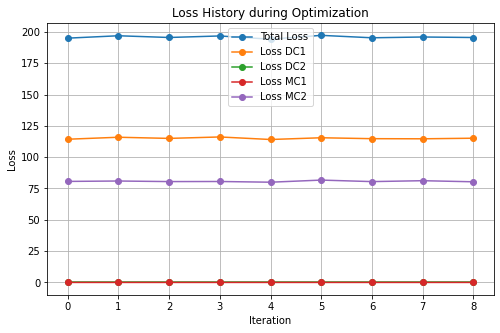

In [5]:
# Plot loss history
plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker="o", label="Total Loss")
plt.plot(loss_DC1_history, marker="o", label="Loss DC1")
plt.plot(loss_DC2_history, marker="o", label="Loss DC2")
plt.plot(loss_MC1_history, marker="o", label="Loss MC1")
plt.plot(loss_MC2_history, marker="o", label="Loss MC2")
plt.title("Loss History during Optimization")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

In [7]:
s_U_opt_noisy, s_Q_opt_noisy = s_U_opt + c_U[1], s_Q_opt + c_Q[1]
residual_U, residual_Q = d_U - s_U_opt_noisy, d_Q - s_Q_opt_noisy

Let's validate the results by visualizing the target maps, the optimized maps, the noisy optimal maps, as well as the contamination maps and the residuals for both U and Q components.

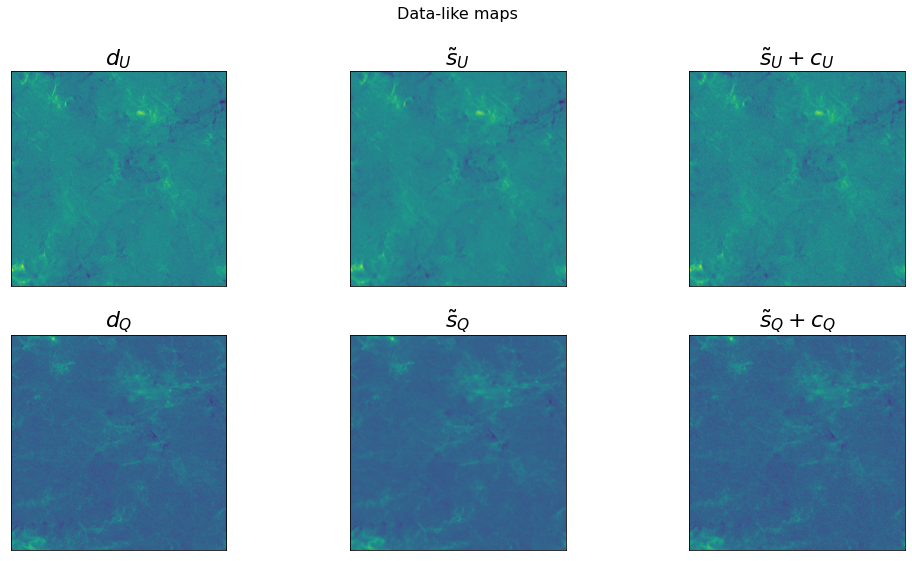

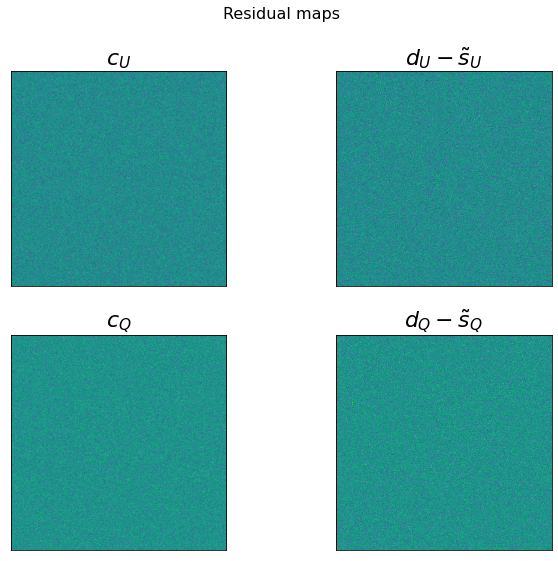

In [18]:
# ============================ Data-like ============================
fig1, axes1 = plt.subplots(2, 3, figsize=(15, 8), facecolor="white")

# common bounds
vmin_U = d_U.min().item()
vmax_U = d_U.max().item()

vmin_Q = d_Q.min().item()
vmax_Q = d_Q.max().item()

# -------- U row --------
axes1[0, 0].imshow(d_U.cpu().numpy(), vmin=vmin_U, vmax=vmax_U, cmap="viridis")
axes1[0, 0].set_title("$d_U$")

axes1[0, 1].imshow(s_U_opt.cpu().numpy(), vmin=vmin_U, vmax=vmax_U, cmap="viridis")
axes1[0, 1].set_title("$\\tilde{s}_U$")

axes1[0, 2].imshow(s_U_opt_noisy.cpu().numpy(), vmin=vmin_U, vmax=vmax_U, cmap="viridis")
axes1[0, 2].set_title("$\\tilde{s}_U + c_U$")

# -------- Q row --------
axes1[1, 0].imshow(d_Q.cpu().numpy(), vmin=vmin_Q, vmax=vmax_Q, cmap="viridis")
axes1[1, 0].set_title("$d_Q$")

axes1[1, 1].imshow(s_Q_opt.cpu().numpy(), vmin=vmin_Q, vmax=vmax_Q, cmap="viridis")
axes1[1, 1].set_title("$\\tilde{s}_Q$")

axes1[1, 2].imshow(s_Q_opt_noisy.cpu().numpy(), vmin=vmin_Q, vmax=vmax_Q, cmap="viridis")
axes1[1, 2].set_title("$\\tilde{s}_Q + c_Q$")

# clean axes
for ax in axes1.flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig1.suptitle("Data-like maps", fontsize=16)

plt.tight_layout()
plt.show()

# ============================ Residuals ============================
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8), facecolor="white")

# bounds from contamination maps
vmin_U_res = c_U[0].min().item()
vmax_U_res = c_U[0].max().item()

vmin_Q_res = c_Q[0].min().item()
vmax_Q_res = c_Q[0].max().item()

# contamination U (reference)
axes2[0, 0].imshow(
    c_U[0].cpu().numpy(),
    vmin=vmin_U_res,
    vmax=vmax_U_res,
    cmap="viridis",
)
axes2[0, 0].set_title("$c_U$")

# residual U
axes2[0, 1].imshow(
    residual_U.cpu().numpy(),
    vmin=vmin_U_res,
    vmax=vmax_U_res,
    cmap="viridis",
)
axes2[0, 1].set_title("$d_U - \\tilde{s}_U$")

# contamination Q (reference)
axes2[1, 0].imshow(
    c_Q[0].cpu().numpy(),
    vmin=vmin_Q_res,
    vmax=vmax_Q_res,
    cmap="viridis",
)
axes2[1, 0].set_title("$c_Q$")

# residual Q
axes2[1, 1].imshow(
    residual_Q.cpu().numpy(),
    vmin=vmin_Q_res,
    vmax=vmax_Q_res,
    cmap="viridis",
)
axes2[1, 1].set_title("$d_Q - \\tilde{s}_Q$")

# clean axes
for ax in axes2.flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig2.suptitle("Residual maps", fontsize=16)

plt.tight_layout()
plt.show()

Validating by plotting the Power Spectrum

In [8]:
stl_c_U = STL_2D_FFT_Torch(array=c_U[2:10].unsqueeze(dim=1), pbc=False)

PS_op = stl_c_U.get_CS_op()

# Observed
PS_d_U = PS_op.apply(STL_2D_FFT_Torch(array=d_U, pbc=True)).abs().cpu().numpy()
PS_s_U_opt_noisy = PS_op.apply(STL_2D_FFT_Torch(array=s_U_opt_noisy, pbc=True)).abs().cpu().numpy()

# Target
PS_s_U = PS_op.apply(STL_2D_FFT_Torch(array=s_U, pbc=True)).abs().cpu().numpy()
PS_s_U_opt = PS_op.apply(STL_2D_FFT_Torch(array=s_U_opt, pbc=True)).abs().cpu().numpy()

# Residuals
PS_c_U = PS_op.apply(stl_c_U)[:, 0, 0, :]
PS_c_U = PS_c_U.abs().cpu().numpy()
PS_c_U_mean = PS_c_U.mean(axis=0)
PS_c_U_min = PS_c_U.min(axis=0)
PS_c_U_max = PS_c_U.max(axis=0)

PS_residual_U = PS_op.apply(STL_2D_FFT_Torch(array=residual_U, pbc=False)).abs().cpu().numpy()

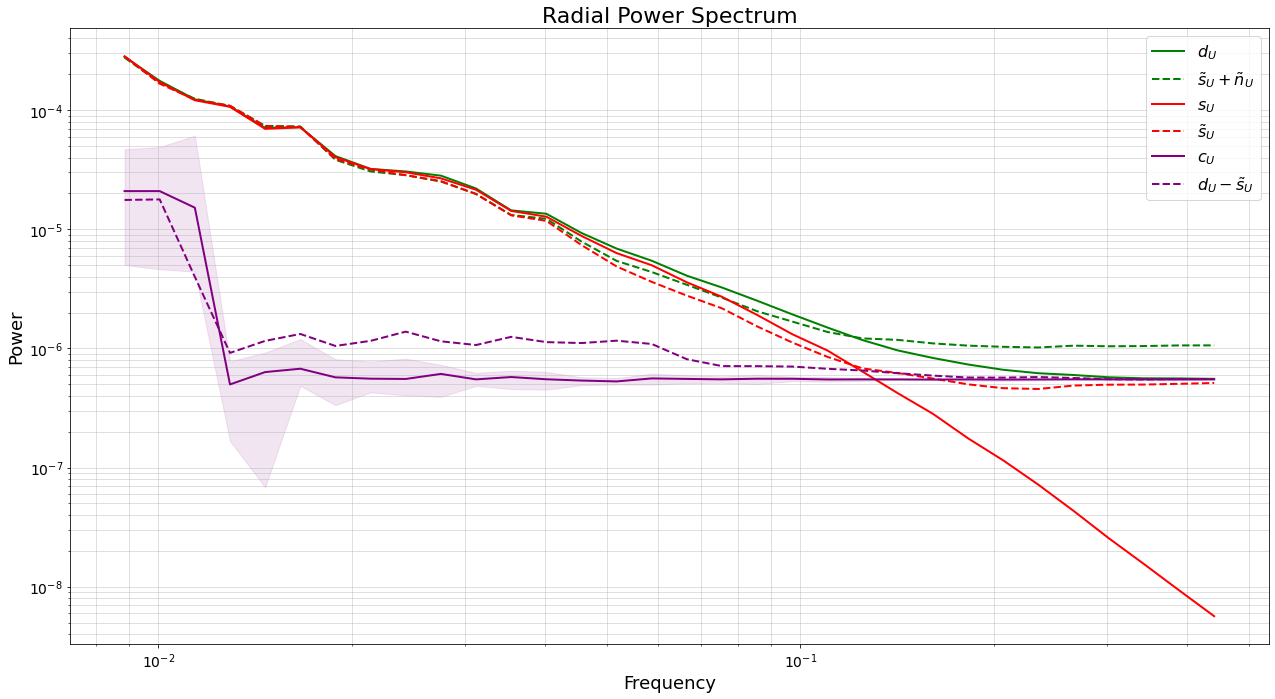

In [9]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

plt.figure(figsize=(18, 10), facecolor="white")

# =============== Observed Power Spectrum Plot =================
plt.plot(
    PS_op.bin_centers,
    PS_d_U.flatten(),
    label="$d_U$",
    linewidth=2,
    color="green",
    linestyle="-"
)

plt.plot(
    PS_op.bin_centers,
    PS_s_U_opt_noisy.flatten(),
    label="$\\tilde{s}_U + \\tilde{n}_U$",
    linewidth=2,
    color="green",
    linestyle="--"
)

# ============== Target Power Spectrum Plot =================
plt.plot(
    PS_op.bin_centers,
    PS_s_U.flatten(),
    label="$s_U$",
    linewidth=2,
    color="red",
    linestyle="-"
)

plt.plot(
    PS_op.bin_centers,
    PS_s_U_opt.flatten(),
    label="$\\tilde{s}_U$",
    linewidth=2,
    color="red",
    linestyle="--"
)

# =============== Residual Power Spectrum Plot =================
plt.plot(
    PS_op.bin_centers,
    PS_c_U_mean,
    label="$c_U$",
    linewidth=2,
    color="purple",
    linestyle="-"
)

plt.fill_between(
    PS_op.bin_centers,
    PS_c_U_min,
    PS_c_U_max,
    color="purple",
    alpha=0.1
)

plt.plot(
    PS_op.bin_centers,
    PS_residual_U.flatten(),
    label="$d_U - \\tilde{s}_U$",
    linewidth=2,
    color="purple",
    linestyle="--"
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Frequency")
plt.ylabel("Power")
plt.title("Radial Power Spectrum")

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()